In [1]:
# load gaussian_annealing_naive_unweighted
import os
import pickle
import sys 

sys.path.append('.')
sys.path.append('..')
sys.path.append('../data')
# from src.plotting import create_all_plots

# print(os.listdir('../data'))

# data = pickle.load(open('polynomial/double_well/leapfrog/cd_unweighted.pkl', 'rb'))


In [2]:
# data['snapshots']['times']

/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_86984/3199092091.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x)  # Normalize
/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_86984/3199092091.py:60: RuntimeWarning: invalid value encountered in log
  empirical_e = compute_expectation_over_equilibrium(particles[:, 0]**2, np.log(weights))


(4000, 1) particles
empirical expectation nan


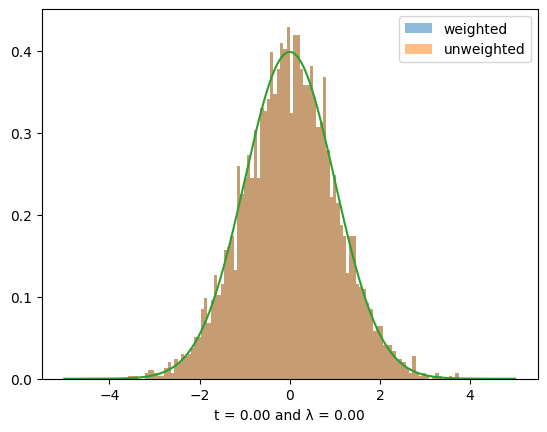

(4000, 1) particles
empirical expectation 1.2164282


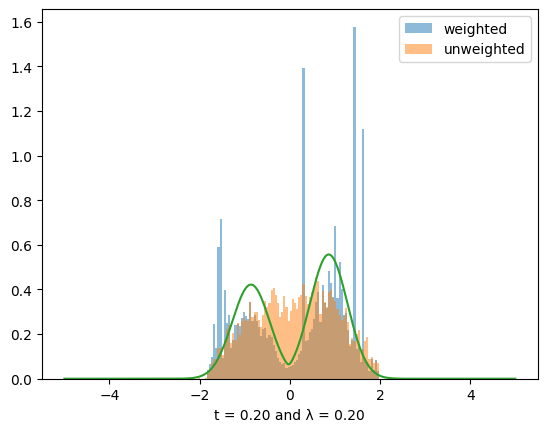

(4000, 1) particles
empirical expectation 1.2757273


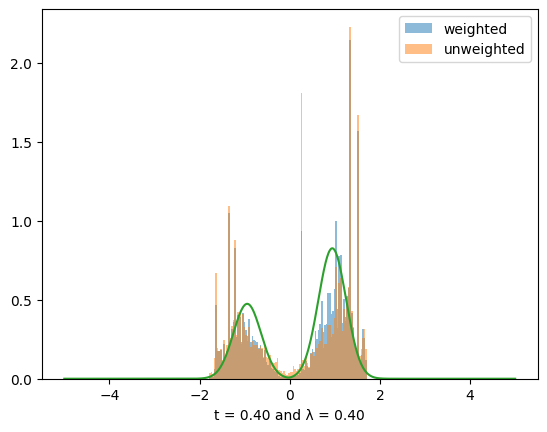

(4000, 1) particles
empirical expectation 1.1416353


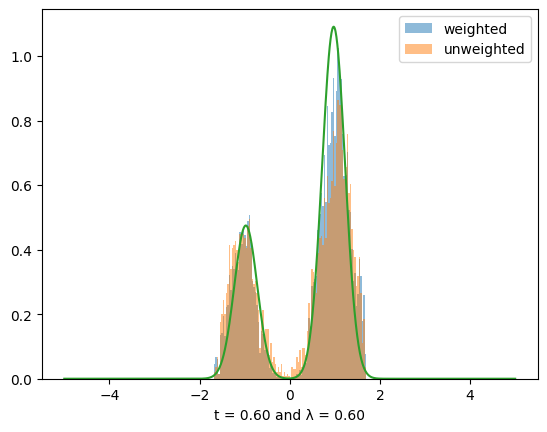

(4000, 1) particles
empirical expectation 1.0915611


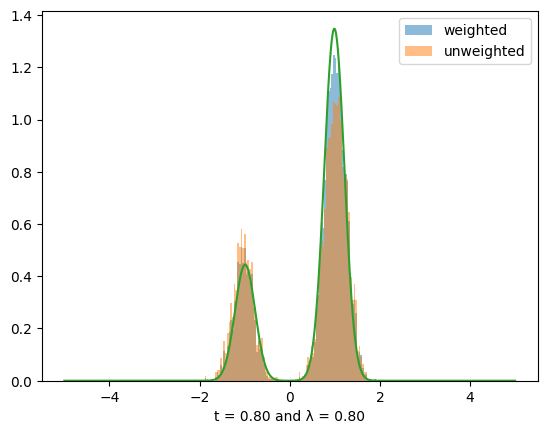

(4000, 1) particles
empirical expectation 1.0660383


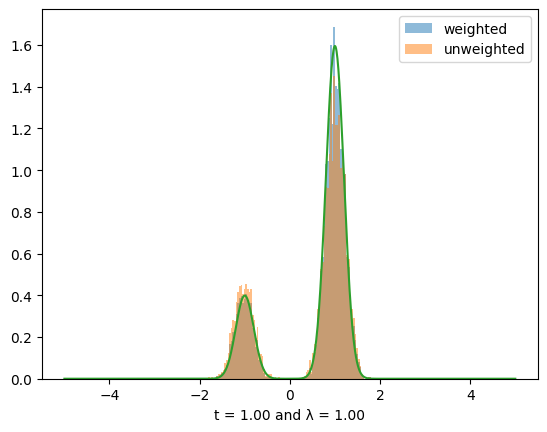

(4000, 1) particles
empirical expectation 1.0516982


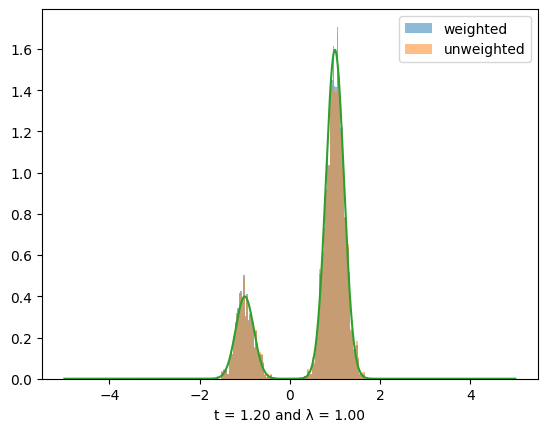

cost: 28000


<Figure size 640x480 with 0 Axes>

In [70]:
# plot a gaussian with unit variance, 1D
import numpy as np
import matplotlib.pyplot as plt
from src.systems import SYSTEMS
import jax.numpy as jnp
# y is a normal pdf (scipy) with std 0.1
from scipy.stats import norm
from src.utils import compute_ess, compute_expectation_over_equilibrium, normalize_log_weights
# y = norm.pdf(x, 0, 1/0.5)



def make_hist(file, system_name):
    data = pickle.load(open(file, 'rb'))

    x = np.linspace(-5, 5, 1000)


    times = data['snapshots']['times']
    # lambdas = times 
    N = len(times)
    M = data['snapshots']['particles'][0].shape[0]
    lambdas = data['snapshots']['lam']
    # print(lambdas)
    # raise Exception("stop")
    # esses = []
    for i in range(len(data['snapshots']['particles'])):
    # for i in range(1):
        potential = SYSTEMS[system_name]['make_V'](lambdas[i])


        # y = potential(x)
        # print(potential(1))
        # raise Exception("stop")
        # normalize y using trapezoid integration
        rho = np.array([np.exp(-potential(point)) for point in x])
        rho = rho / np.trapz(rho, x)  # Normalize

        # print(times[i])

        # particles = data['snapshots']['particles_before_resampling'][i]
        # log_weights = data['snapshots']['weights_before_resampling'][i]
        particles = data['snapshots']['particles'][i]
        weights = data['snapshots']['weights'][i]
        print(particles.shape, "particles")

        
        all_weights = np.exp(data['snapshots']['weights'])
        all_weights = jnp.clip(all_weights, 0, 1).mean(axis=-1)


        # compute ess of weights 
        # ess = compute_ess(log_weights)
        # print(ess)
        # esses.append(ess)

        # expect = jnp.sum(weights * (particles**2)[:, 0], axis=0)
        # print(expect, "expectation", weights.shape, particles.shape, (weights * (particles**2)[:, 0]).shape)

        empirical_e = compute_expectation_over_equilibrium(particles[:, 0]**2, np.log(weights))
        print("empirical expectation",empirical_e)

        # all_weights = all_weights.mean(axis=-1)
        
        num_bins = 100
        plt.hist(particles[:,0], bins=num_bins, weights=weights, density=True, alpha=0.5, label='weighted')
        plt.hist(particles[:,0], bins=num_bins, density=True, alpha=0.5, label='unweighted')
        plt.plot(x, rho)
        plt.xlabel(f't = {times[i]:.2f} and λ = {lambdas[i]:.2f}')
        plt.legend()
        plt.show()
        plt.clf()


    # plt.plot(all_weights)
    # print(data)
    # plt.show()
    # plt.plot(esses)

    true_expectation = 0.1
    error = ((empirical_e - true_expectation)**2) / (2 * true_expectation)
    # print(f'error: {error} and ESS: {100/error}')
    cost_per_step = 1
    cost = cost_per_step * N * M 
    print(f'cost: {cost}')



# error_cd, estimate_cd = calculate_normalized_error(
#                     final_samples_cd, true_exp, true_var, f_func
#                 )


# system_name = 'gaussian_annealing'
system_name = 'mixture'
# system_name = 'gaussian_moving_mean'

# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=0)
# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=20)
# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_unweighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_weighted.pkl', i=20)

make_hist(file=f'polynomial/{system_name}/leapfrog/cd_weighted.pkl', system_name=system_name)
# make_hist(file=f'mixture_smc_adjusted_hmc.pkl', system_name=system_name)

# make_hist(file=f'naive/{system_name}/leapfrog/naive_weighted.pkl', system_name=system_name)

In [ ]:
from src.simple_benchmark import calculate_double_well_expectations

    
true_expectations = calculate_double_well_expectations(2.0)
true_expectations

{'x_squared': {'expectation': 14.6827908, 'variance': 17.694268}}

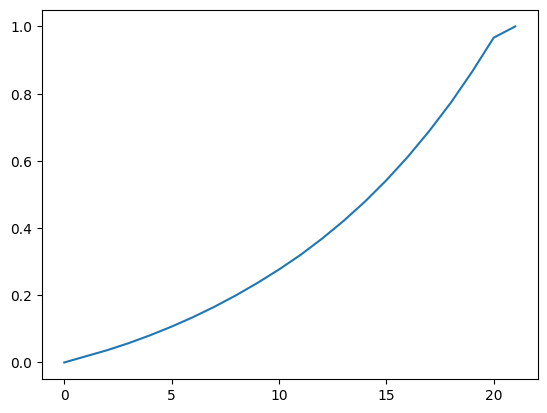

In [23]:
schedule = [0.0, 0.018310546875, 0.036585405468940735, 0.05751897394657135, 0.08098895847797394, 0.10679127275943756, 0.13503114879131317, 0.1660737246274948, 0.19997233152389526, 0.23688766360282898, 0.27675729990005493, 0.32001766562461853, 0.36832696199417114, 0.42091497778892517, 0.4785972833633423, 0.542245090007782, 0.6122046709060669, 0.6890820860862732, 0.77288419008255, 0.8658154010772705, 0.966715931892395, 1.0]

plt.plot(schedule)